# 03_Preprocessing

Electroencephalography (EEG) records the tiny electrical signals from you brain, but because those signals are so weak, the sensors also pick up a lot of "junk" (artifacts) from the body and the environment.

Raw EEG signals contain noise from many sources that must be removed before analysis:

| Artifact | Source | Removal |
|----------|--------|---------|
| Slow drifts | Sweat, electrode movement | High-pass filter |
| Muscle noise | EMG | Low-pass filter |
| Power line | Electrical interference | Notch filter (60 Hz) |
| Eye blinks / movements | EOG | ICA |
| Bad channels | Loose/broken electrode | Detect → interpolate |
| Noisy epochs | Movement, coughing | Amplitude rejection |

We remove these artifacts because they can be much stronger than brain waves, effecting drowning out the actual data you're trying to study.

The Removal Methods:  
- Filters: Think of these like a sieve. A high-pass lets fast signals through and blocks "slow" drifts. A Low-pass blocks fast muscle noise. A Notch filter sspecificaally targets just that one 60 Hz frequency.
- ICA (Independent Component Analysis): This is like un-mixing a smoothie. It identifies the "Eye blink" pattern and substracts it from the data without deleting the brain activity underneath it.
- Interpolation: If one sensor is broken, we look at its neighbors and "guess" what the signal should have been based on their avarage.

> In EEG research, "clean" data is often more important than "more" data. If you don't remove these, you might accidentally end up studying someone's sweat glands instead of their throughts.

**Dataset channels:** 32 EEG (10-20 system) + 8 EXG (BioSemi external = EOG) + 1 trigger  
**Sampling rate:** 512 Hz  
**Recording length:** ~192 s per session

## 1. Preparations

### 1.1. Import Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals
from mne.preprocessing import ICA
from pyprep.find_noisy_channels import NoisyChannels

### 1.2. Configurations

In [2]:
mne.set_log_level('WARNING')
warnings.filterwarnings('ignore', message='Unable to map the following column', category=RuntimeWarning)

BIDS_ROOT  = os.path.join('datasets', 'ds002778')
SAVE_DIR   = 'processed'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Preprocessing parameters ──────────────────────────────────────────────
L_FREQ      = 1.0    # high-pass Hz — removes slow drifts
H_FREQ      = 40.0   # low-pass Hz  — removes muscle noise
NOTCH_FREQ  = 60.0   # power line (60 Hz North America)
EPOCH_LEN   = 2.0    # seconds per epoch
AMP_THRESH  = 150e-6 # rejection threshold (150 µV) — 99th pct is ~121 µV
N_ICA_COMP  = 20     # ICA components to fit

print('Setup complete.')
print(f'  Bandpass  : {L_FREQ}–{H_FREQ} Hz')
print(f'  Notch     : {NOTCH_FREQ} Hz')
print(f'  Epoch len : {EPOCH_LEN} s')
print(f'  AMP thresh: {AMP_THRESH*1e6:.0f} µV')

Setup complete.
  Bandpass  : 1.0–40.0 Hz
  Notch     : 60.0 Hz
  Epoch len : 2.0 s
  AMP thresh: 150 µV


| Setting | Purpose | Target |
|---------|---------|--------|
| Bandpass | Keep brainwaves | Remove slow drift & high noise |
| Notch | Remove power line hum | 60 Hz electrical interference |
| Epoch | Chop data | Create 2-second analysis windows |
| Threshold | Quality control | Delete segments with huge movement| 

## 2. Preprocessing

We first run the full pipeline on a single subject to verify each step before processing all subjects.

### Step 1: Data Loading and Configuration -- Load & Inspect One Subject

.bdf* is the file format used by BioSemi EEG systems. In contains the raw voltage fluctuations recorded from the scalp.  

> BIDS is a standardized way of naming and organizing neuroimaging folders. By using it, the code automatically knows where to find the metadata (like channel names and participant info) without you having to type in the exact file path manually.

In [3]:
subjects = get_entity_vals(BIDS_ROOT, 'subject')
hc_subs  = [s for s in subjects if 'hc' in s.lower()]
pd_subs  = [s for s in subjects if 'pd' in s.lower()]

sub, ses = hc_subs[0], 'hc'
print(f'Loading sub-{sub} ses-{ses}...')

bp  = BIDSPath(subject=sub, session=ses, task='rest', datatype='eeg', root=BIDS_ROOT)
raw = read_raw_bids(bp, verbose=False).load_data()

print(f'Channels      : {len(raw.ch_names)}')
print(f'Sampling rate : {raw.info["sfreq"]} Hz')
print(f'Duration      : {raw.times[-1]:.1f} s')

Loading sub-hc1 ses-hc...
Channels      : 41
Sampling rate : 512.0 Hz
Duration      : 192.0 s


**Explanation:**  
<u>Channels: 41</u>, This matches the setup from your previous image.
> - 32 EEG channels (the sensors on the scalp)
> - 8 EXG channels (the external senesors for the eyes/muscles)
> - 1 trigger channel (a digital marker that records exactly when a stimulus or event happened)

<u>Sampling Rate: 512.0 Hz</u>, describes the "resolution" of the recording in time.
> - 512 Hz means the equipment took a snapshot of the brain's electrical activity 512 times every second.
> - This is a solid research-grade sampling rate, allowing you to accurately see brain frequencies up to about 256 Hz (though your pipeline filters it down to 40 Hz anyway).

<u>Duration: 192.0 s</u>, This is the total length of the recording session.
> - 192 seconds = 3 minutes and 12 seconds.
> - If you apply your 2-second Epoch setting from earlier to this file, you will end up with exactly 96 epochs (segments) to analyze 192 / 2 = 96.


### Step 2: Data Loading and Configuration -- Set Montage + Reclassify EXG (External/Auxiliaary Channels) as EOG (Electrooculography)

The "montage" tells the software where each electrode was placed on the head (using the standard 10-20 system). EOG refers to electrodes placed near the eyes to track blinks and eye movements, which the system needs to distinguish from actual brain activitiy.  

- **Montage** assigns 3D electrode positions to channel names.  
Required for: pyprep bad channel detection, topomaps, source localization.

- **EXG channels** are BioSemi external electrodes — in this dataset they capture eye movements (EOG).  
Reclassifying them lets MNE use them automatically during ICA artifact detection.

In [4]:
# Setting the Sensor Map (Montage): Set standard 10-20 montage (matches EEG channel names)
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
# What it does: It loads the standard_1020 system (a worldwide standard for electrode placement).
# Why it matters: Without this, the software just sees a list of numbers. By setting a montage, the software knows the 3D coordinates of each sensor, allowing you to create heatmaps (topomaps) of brain activity later.

# Reclassify EXG channels as EOG
exg_chs = [c for c in raw.ch_names if c.startswith('EXG')] 
raw.set_channel_types({ch: 'eog' for ch in exg_chs})
# What it does: It renames these from "Exogenous" (generic) to eog (Electrooculogram).
# Why it matters: eog channels specifically measure eye movements. By telling MNE these are eye channels, the ICA algorithm can later use them as a reference to identify which brain signals are actually just eye blinks.

# Branch ICA copy HERE — before the bandpass filter is applied.
# ICA needs access to the full artefact bandwidth; branching after bandpass
# would limit ICA to 1-40 Hz and degrade blink/saccade component separation.
# This is the most technically important part of the code. It creates a copy of the data specifically for calculating the ICA.
raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

print(f'Montage set  : {len([d for d in raw.info["dig"] if d["kind"]==3])} electrode positions')
print(f'EOG channels : {exg_chs}')
print(f'ICA copy ready (1 Hz high-pass, pre-bandpass)')

Montage set  : 32 electrode positions
EOG channels : ['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
ICA copy ready (1 Hz high-pass, pre-bandpass)


**Explanation:**    
The EEG preprocessing pipeline began by mapping the recorded data to a standard 10-20 montage (32 electroduce positions) to establish spatial coordinates for subsequent topographical analyssis. To assist in artifact identification, eight external channels (EXG1 - EXG8) Were reclassified as Electrooculogram (EOG) channels to specifically monitor eye movements. Finally, a dedicated ICA-ready data branch was creaated by applying a 1.0 Hz high-pass; this specific filtering strategy was used to remove low-frequency electrude drifts, thereby optimizing the signal-to-noise ratio for the upcoming Independent Component Analysis (ICA) without altering the original raw data.

### Step 3: Filtering the Noise

**Bandpass (1–40 Hz):**  
- 1 Hz high-pass removes slow baseline drifts (sweat, DC offset)  
- 40 Hz low-pass removes high-frequency muscle (EMG) artifacts  
- Keeping only the frequencies where most cofnitive brain activities happens.  

**Notch (60 Hz):**  
- Removes AC power line interference (60 Hz in North America), This specifically targets electrical "hum" from wall outlets and equipment, which in North America vibrates at exactly 60 Hz.  

C:\Users\User\AppData\Local\Temp\ipykernel_7024\4267237083.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


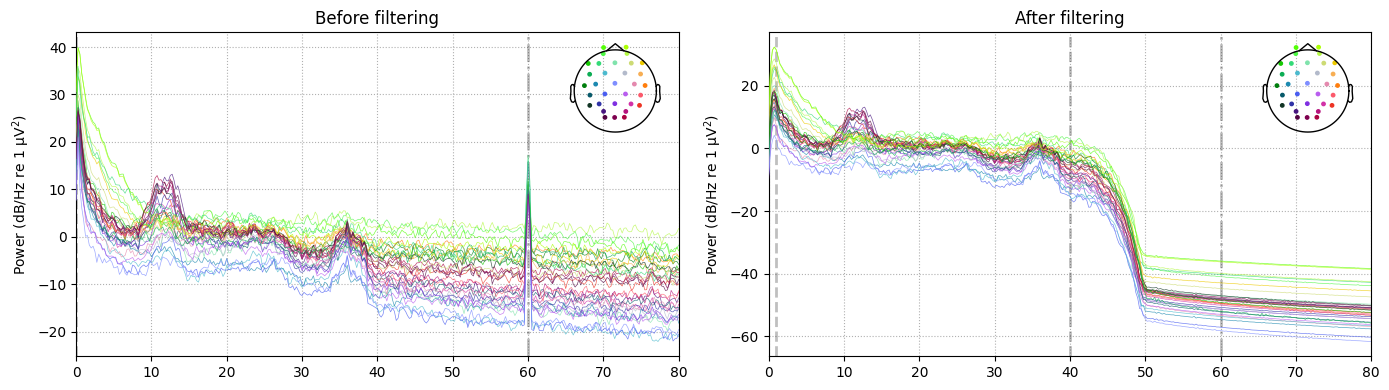

Filtering done.


In [5]:
raw_prefilt = raw.copy()  # keep for before/after comparison

# Notch FIRST — eliminate 60 Hz line noise before bandpass.
# Applying notch after a 40 Hz low-pass would make it a no-op (60 Hz already gone).
raw.notch_filter(freqs=NOTCH_FREQ)
raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, method='fir', fir_window='hamming')

# Compare PSD before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_prefilt.compute_psd(fmax=80, picks='eeg').plot(axes=axes[0], show=False)
axes[0].set_title('Before filtering')
raw.compute_psd(fmax=80, picks='eeg').plot(axes=axes[1], show=False)
axes[1].set_title('After filtering')
plt.tight_layout()
plt.show()
print('Filtering done.')

**Explanation:**  
- The filter process successfully isolated the relevant EEG signal by targeting both environmental noise and physiological artifacts.
- The **notch filter** effectively eliminated the sharp 60 Hz spike caused by electrical line interference, while the **bandoass filter** restricted the data to the dessired frequency range (likely 1-40 Hz), as evidenced by the significant drop in power beyond 40 Hz in the "After giletring" plot. 
- Additionally, pre-filtering "Before" plot shows high-amplitude activity at very low frequencies (<  1Hz) --typical of slow-drift artifacts like movement or perspiration --which has been stabilized in the processed output.
- This refinement ensures that the remaining Power Spectral Density (PSD) peaks, such as the prominent **Alpha band activity** around 10-20 Hz, are clearly visible and ready for quantitative analysis without contamination from external noise.

### Step 4: Cleaning the Channels -- Bad Channel Detection & Interpolation

If one electrode had a poor connection (e.g., loose wire), it produces "garbage" data. Instead of throwing away the whole session, researchers use math to estimate what that channel should have recorded based on the surrounding healthy electrodes.    

Using **pyprep** (Python implementation of the PREP pipeline — standard in EEG research).  
Run *before* average re-referencing — the PREP pipeline requires this order.

Bad channels are reconstructed via **spherical spline interpolation** from neighbouring electrodes.

In [6]:
raw_precleanchan = raw.copy() # for comparison before after

try:
    # NoisyChannels expects a pure-EEG input — passing mixed EEG+EOG corrupts
    # the correlation/RANSAC statistics. Use a picks-restricted copy.
    nd = NoisyChannels(raw.copy().pick('eeg'), random_state=42)
    nd.find_all_bads()
    bads = nd.get_bads()
    print(f'Bad channels detected: {bads if bads else "none"} ({len(bads)})')
    if bads:
        raw.info['bads'] = bads
        raw.interpolate_bads(reset_bads=True)
        print('Interpolation done.')
except Exception as e:
    print(f'pyprep skipped: {e}')

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bad channels detected: ['F3', 'Cz', 'AF3', 'AF4', 'C3'] (5)
Interpolation done.


### Step 5: Cleaning the Channels -- Average Re-referencing

EEG measures the difference in voltage between two points. "Re-referencing" creates a stable baseline by subtracting the average of all electrodes from each individual electrode.  

EEG voltages are relative to a reference electrode. **Average reference** is standard for resting-state:  
subtracts the mean of all electrodes at each time point, making the data reference-independent.  

> Note: done *after* bad channel interpolation to avoid bad channels contaminating the average.

Average reference applied.


C:\Users\User\AppData\Local\Temp\ipykernel_7024\1509547024.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


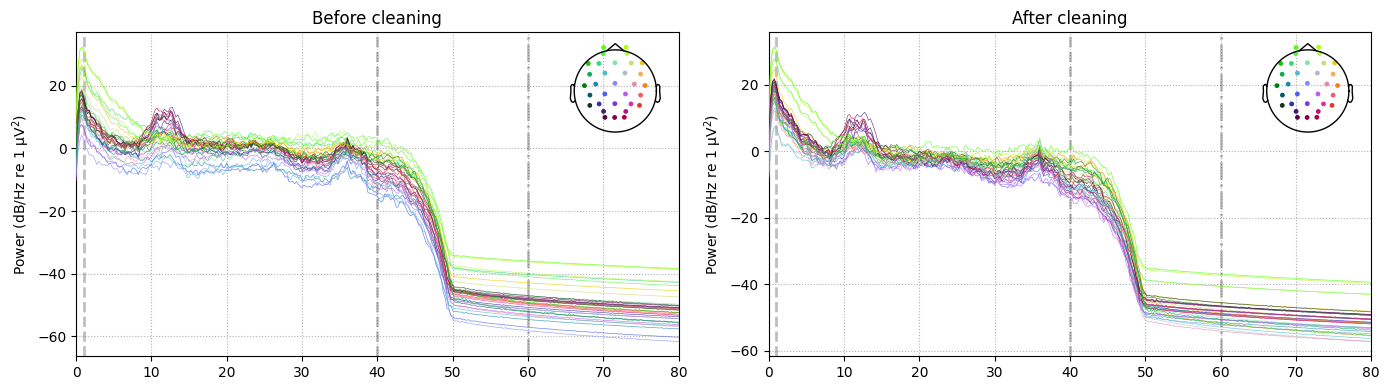

In [7]:
raw.set_eeg_reference('average', projection=True)
raw.apply_proj()
print('Average reference applied.')

# Compare before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_precleanchan.compute_psd(fmax=80, picks='eeg').plot(axes=axes[0], show=False)
axes[0].set_title('Before cleaning')
raw.compute_psd(fmax=80, picks='eeg').plot(axes=axes[1], show=False)
axes[1].set_title('After cleaning')
plt.tight_layout()
plt.show()

### Step 6: Removing Artifacts (Blinks) -- ICA (Independent Component Analysis)

This is a powerful algorithm that "unmixes" the data. It identifies specific patterns that look like eye blinks and separates them from the brain signals.
Once identified, the computer "deletes" the blink patterns while leaving the underlying brain activity intact.  

ICA separates the EEG signal into statistically independent components.  
Eye blinks and saccades produce large, spatially stable components that can be automatically identified  
by correlating ICA sources with the EOG channels (EXG1–EXG8).

`raw_for_ica` was branched in Step 2 **before** the bandpass filter — this matters because:
- Artefacts (blinks, saccades) have energy across the full spectrum, not just 1–40 Hz
- Fitting ICA on pre-bandpass data gives the algorithm the broadest signal representation, improving component separation
- The ICA solution (component weights) is then applied to the properly filtered `raw`

> Electrooculography (EOG) is a diagnostic technique that measures the resting electrical potential between the cornea and the retina

In [8]:
# raw_for_ica was created in Step 2 (pre-bandpass) — use it directly here.
ica = ICA(n_components=N_ICA_COMP, random_state=42, method='fastica')
ica.fit(raw_for_ica, picks='eeg')

# Use mne.pick_types — canonical, version-stable alternative to mne.channel_type()
eog_chs = [raw.ch_names[i] for i in mne.pick_types(raw.info, eog=True)]
eog_indices = []
for eog_ch in eog_chs[:2]:  # first 2 EXG channels capture blink + saccade
    found, _ = ica.find_bads_eog(raw, ch_name=eog_ch)
    eog_indices.extend(found)
eog_indices = list(set(eog_indices))

print(f'EOG artifact components: {eog_indices}')

# Visualise the identified components
if eog_indices:
    ica.plot_components(picks=eog_indices, title='Components to remove')
    plt.show()

EOG artifact components: []


Removing the Blink noise from the data.

Removed 0 component(s). Signal cleaned.


C:\Users\User\AppData\Local\Temp\ipykernel_7024\1492104773.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


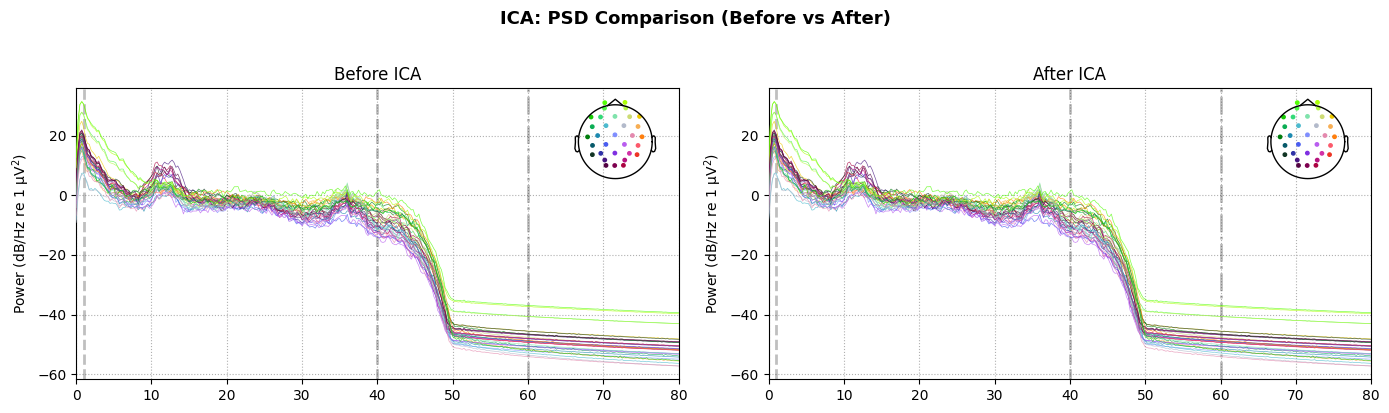

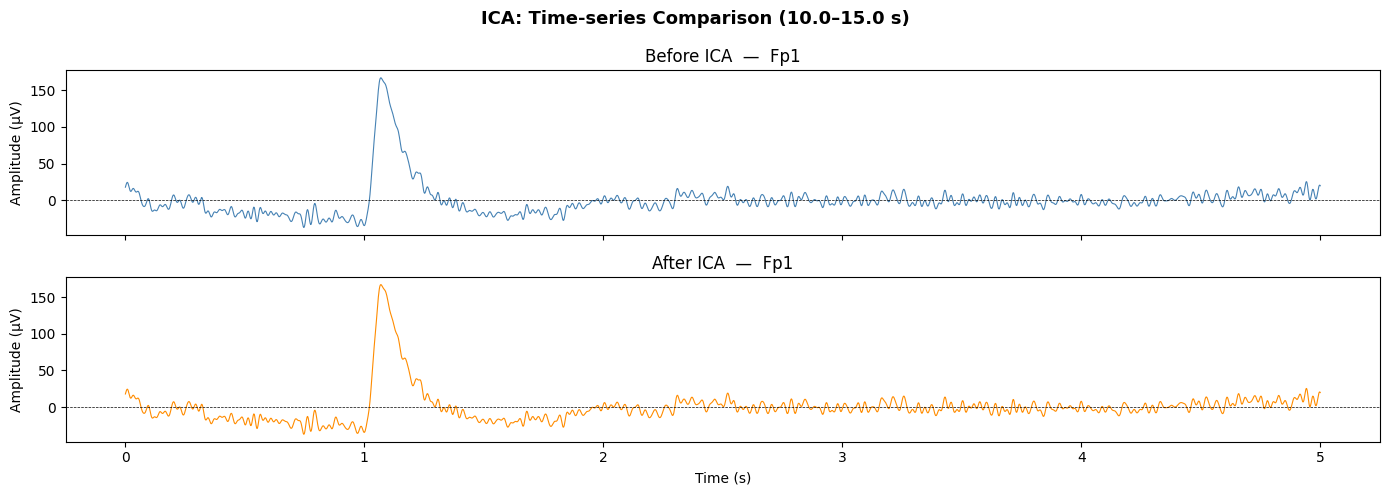

In [9]:
# Capture state before ICA removal for comparison
raw_pre_ica = raw.copy()

# Apply — remove EOG components from the signal
ica.exclude = eog_indices
ica.apply(raw)
print(f'Removed {len(ica.exclude)} component(s). Signal cleaned.')

# ── Before/After ICA: PSD comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_pre_ica.compute_psd(fmax=80, picks='eeg').plot(axes=axes[0], show=False)
axes[0].set_title('Before ICA')
raw.compute_psd(fmax=80, picks='eeg').plot(axes=axes[1], show=False)
axes[1].set_title('After ICA')
plt.suptitle('ICA: PSD Comparison (Before vs After)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Before/After ICA: Time-series on a frontal channel ───────────────────────
# Frontal channels (Fp1/Fp2) are most affected by eye-blink artifacts
t_start, t_stop = 10.0, 15.0   # 5-second window
frontal_chs = [c for c in ['Fp1', 'Fp2', 'F3', 'F4'] if c in raw.ch_names]
ch_pick = frontal_chs[0] if frontal_chs else raw.ch_names[0]

pre_data, times = raw_pre_ica.copy().crop(t_start, t_stop)[ch_pick]
post_data, _    = raw.copy().crop(t_start, t_stop)[ch_pick]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(times, pre_data[0] * 1e6, lw=0.8, color='steelblue')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].set_title(f'Before ICA  —  {ch_pick}')
axes[0].axhline(0, color='k', lw=0.5, linestyle='--')

axes[1].plot(times, post_data[0] * 1e6, lw=0.8, color='darkorange')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'After ICA  —  {ch_pick}')
axes[1].axhline(0, color='k', lw=0.5, linestyle='--')

plt.suptitle(f'ICA: Time-series Comparison ({t_start}–{t_stop} s)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Segmentation -- Epoching

Continuous data is chopped into small, manageable windows (epochs). This allows researchers to analyze specific moments in time.  

Epoching in Neuroscience (EEG/MEG) is Extracting short, discrete time-windows (epochs) from continuous data, usually time-locked to a specific stimulus or response. To analyze brain activity related to specific events (e.g., event-related potentials or ERPs). A typical epoch includes a pre-stimulus baseline interval for normalization and an post-stimulus interval, such as -200ms to 1000ms. Involves segmenting the continuous data based on trigger markers and often applying baseline correction to remove noise. 

Resting-state has no stimulus events, so we use **fixed-length epochs** (sliding window).  

- **2 seconds** per epoch: enough for reliable band power estimates (≥5 cycles at 2.5 Hz)  
- **No overlap**: keeps epochs independent for cross-validation  
- **EEG channels only**: EOG channels dropped before saving

In [10]:
# Pick EEG only before epoching
raw_eeg = raw.copy().pick('eeg')

epochs = mne.make_fixed_length_epochs(
    raw_eeg,
    duration=EPOCH_LEN,
    overlap=0.0,
    preload=True
)
print(f'Epochs created: {len(epochs)}')

Epochs created: 96


## Step 8: Segmentation -- Epoch Rejection

Reject high-amplitude epochs ($>150$ µV), If a subject sneezed or moved their head significantly, the voltage spike would be huge. This step automatically throws out any segments that are too "messy" to be real brain signals.  

Reject any remaining epochs where a channel exceeds **150 µV**.  
(99th percentile of this dataset is ~121 µV, so 150 µV is conservative.)

Epochs kept    : 55
Duration kept  : 110.0 s  (1.8 min)


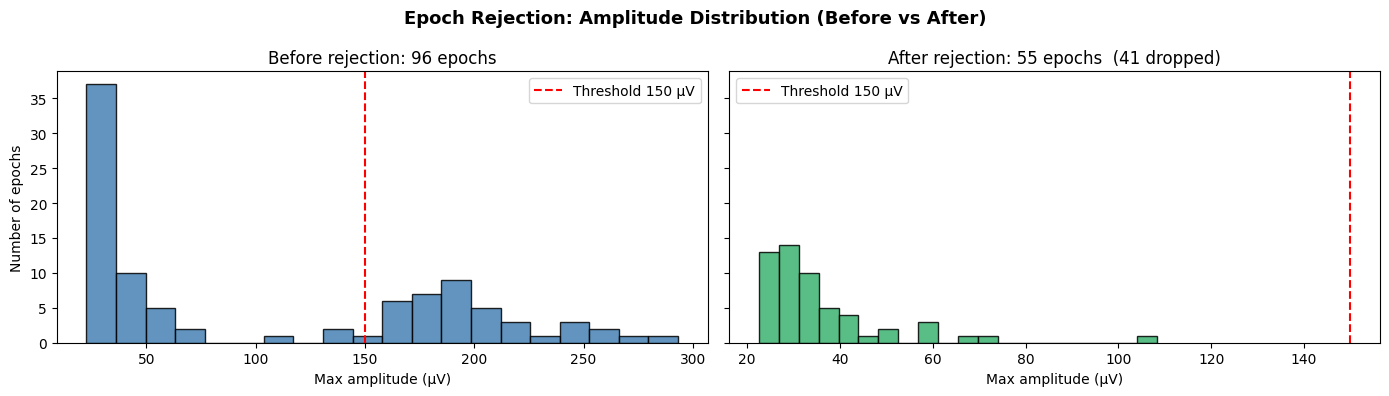

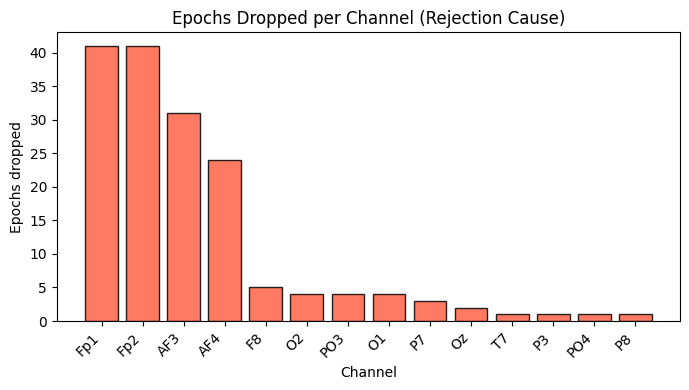

In [11]:
# Capture epoch data BEFORE rejection for comparison
n_before = len(epochs)
epochs_data_before = epochs.get_data()  # (n_epochs, n_channels, n_times)

epochs.drop_bad(reject={'eeg': AMP_THRESH})

n_kept = len(epochs)
print(f'Epochs kept    : {n_kept}')
print(f'Duration kept  : {n_kept * EPOCH_LEN:.1f} s  ({n_kept * EPOCH_LEN / 60:.1f} min)')

# ── Amplitude distribution: Before vs After ───────────────────────────────────
max_amps_before = np.abs(epochs_data_before).max(axis=(1, 2)) * 1e6
max_amps_after  = np.abs(epochs.get_data()).max(axis=(1, 2)) * 1e6
thresh_uv = AMP_THRESH * 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].hist(max_amps_before, bins=20, color='steelblue', edgecolor='k', alpha=0.85)
axes[0].axvline(thresh_uv, color='red', linestyle='--', linewidth=1.5, label=f'Threshold {thresh_uv:.0f} µV')
axes[0].set_xlabel('Max amplitude (µV)')
axes[0].set_ylabel('Number of epochs')
axes[0].set_title(f'Before rejection: {n_before} epochs')
axes[0].legend()

axes[1].hist(max_amps_after, bins=20, color='mediumseagreen', edgecolor='k', alpha=0.85)
axes[1].axvline(thresh_uv, color='red', linestyle='--', linewidth=1.5, label=f'Threshold {thresh_uv:.0f} µV')
axes[1].set_xlabel('Max amplitude (µV)')
axes[1].set_title(f'After rejection: {n_kept} epochs  ({n_before - n_kept} dropped)')
axes[1].legend()

plt.suptitle('Epoch Rejection: Amplitude Distribution (Before vs After)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Per-channel drop count ────────────────────────────────────────────────────
drop_log = epochs.drop_log   # tuple of tuples
ch_drop_counts = {}
for reasons in drop_log:
    for ch in reasons:
        ch_drop_counts[ch] = ch_drop_counts.get(ch, 0) + 1

if ch_drop_counts:
    ch_names_sorted = sorted(ch_drop_counts, key=ch_drop_counts.get, reverse=True)
    counts_sorted   = [ch_drop_counts[c] for c in ch_names_sorted]

    fig, ax = plt.subplots(figsize=(max(6, len(ch_names_sorted) * 0.5), 4))
    ax.bar(ch_names_sorted, counts_sorted, color='tomato', edgecolor='k', alpha=0.85)
    ax.set_xlabel('Channel')
    ax.set_ylabel('Epochs dropped')
    ax.set_title('Epochs Dropped per Channel (Rejection Cause)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No epochs were dropped due to amplitude threshold.')

## Step 9: Save

Save cleaned epochs as MNE `.fif` format into `processed/`.  
This directory is in `.gitignore` and will not be committed.

In [12]:
save_path = os.path.join(SAVE_DIR, f'sub-{sub}_ses-{ses}-epo.fif')
epochs.save(save_path, overwrite=True)
print(f'Saved: {save_path}')

Saved: processed\sub-hc1_ses-hc-epo.fif


## Step 10: Run Full Pipeline on All Subjects

Process all 31 subjects across all sessions:

| Group | Session | n subjects |
|-------|---------|------------|
| HC | `ses-hc` | 16 |
| PD | `ses-off` | 15 |
| PD | `ses-on` | 15 |

In [13]:
def preprocess_subject(sub, ses):
    """Full preprocessing pipeline for one subject/session.
    Returns cleaned Epochs, or None on failure.
    Skips if output file already exists.
    """
    save_path = os.path.join(SAVE_DIR, f'sub-{sub}_ses-{ses}-epo.fif')
    if os.path.exists(save_path):
        print(f'  sub-{sub} ses-{ses}: already exists, skipping')
        return mne.read_epochs(save_path, verbose=False)

    try:
        # 1. Load
        bp  = BIDSPath(subject=sub, session=ses, task='rest', datatype='eeg', root=BIDS_ROOT)
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=RuntimeWarning)
            raw = read_raw_bids(bp, verbose=False).load_data()

        # 2. Montage + channel types
        raw.set_montage(mne.channels.make_standard_montage('standard_1020'), on_missing='ignore')
        exg = [c for c in raw.ch_names if c.startswith('EXG')]
        raw.set_channel_types({c: 'eog' for c in exg})

        # Branch ICA copy BEFORE bandpass
        raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

        # 3. Filter — notch first, then bandpass
        raw.notch_filter(freqs=NOTCH_FREQ, verbose=False)
        raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, method='fir', fir_window='hamming', verbose=False)

        # 4. Bad channels (before re-reference) — EEG-only copy for pyprep
        try:
            nd = NoisyChannels(raw.copy().pick('eeg'), random_state=42)
            nd.find_all_bads()
            bads = nd.get_bads()
            if bads:
                raw.info['bads'] = bads
                raw.interpolate_bads(reset_bads=True)
        except Exception:
            pass

        # 5. Re-reference
        raw.set_eeg_reference('average', projection=True)
        raw.apply_proj()

        # 6. ICA — fit on pre-bandpass copy, apply to filtered raw
        ica = ICA(n_components=N_ICA_COMP, random_state=42, method='fastica')
        ica.fit(raw_for_ica, picks='eeg')
        eog_chs = [raw.ch_names[i] for i in mne.pick_types(raw.info, eog=True)]
        idx = []
        for eog_ch in eog_chs[:2]:
            found, _ = ica.find_bads_eog(raw, ch_name=eog_ch)
            idx.extend(found)
        ica.exclude = list(set(idx))
        ica.apply(raw)

        # 7. Epoch (EEG only)
        raw_eeg = raw.copy().pick('eeg')
        epochs  = mne.make_fixed_length_epochs(raw_eeg, duration=EPOCH_LEN, overlap=0.0, preload=True)

        # 8. Reject
        epochs.drop_bad(reject={'eeg': AMP_THRESH})

        # 9. Save
        if len(epochs) == 0:
            print(f'  sub-{sub} ses-{ses}: WARNING — 0 epochs remain, skipping save')
            return None
        epochs.save(save_path, overwrite=True)
        print(f'  sub-{sub} ses-{ses}: {len(epochs)} epochs -> {save_path}')
        return epochs

    except Exception as e:
        print(f'  sub-{sub} ses-{ses}: FAILED — {e}')
        return None

In [14]:
to_process = (
    [(s, 'hc')  for s in hc_subs] +
    [(s, 'off') for s in pd_subs] +
    [(s, 'on')  for s in pd_subs]
)

print(f'Processing {len(to_process)} subject-sessions...\n')
results = {}
for sub, ses in to_process:
    results[(sub, ses)] = preprocess_subject(sub, ses)

succeeded = sum(1 for v in results.values() if v is not None)
print(f'\nDone: {succeeded}/{len(to_process)} succeeded.')

Processing 46 subject-sessions...

  sub-hc1 ses-hc: already exists, skipping
  sub-hc10 ses-hc: 96 epochs -> processed\sub-hc10_ses-hc-epo.fif
  sub-hc18 ses-hc: 87 epochs -> processed\sub-hc18_ses-hc-epo.fif
  sub-hc2 ses-hc: 89 epochs -> processed\sub-hc2_ses-hc-epo.fif
  sub-hc20 ses-hc: 92 epochs -> processed\sub-hc20_ses-hc-epo.fif
  sub-hc21 ses-hc: 32 epochs -> processed\sub-hc21_ses-hc-epo.fif
  sub-hc24 ses-hc: 36 epochs -> processed\sub-hc24_ses-hc-epo.fif
  sub-hc25 ses-hc: 99 epochs -> processed\sub-hc25_ses-hc-epo.fif
  sub-hc29 ses-hc: 60 epochs -> processed\sub-hc29_ses-hc-epo.fif
  sub-hc30 ses-hc: 42 epochs -> processed\sub-hc30_ses-hc-epo.fif
  sub-hc31 ses-hc: 83 epochs -> processed\sub-hc31_ses-hc-epo.fif
  sub-hc32 ses-hc: 98 epochs -> processed\sub-hc32_ses-hc-epo.fif
  sub-hc33 ses-hc: 93 epochs -> processed\sub-hc33_ses-hc-epo.fif
  sub-hc4 ses-hc: 88 epochs -> processed\sub-hc4_ses-hc-epo.fif
  sub-hc7 ses-hc: 79 epochs -> processed\sub-hc7_ses-hc-epo.fif
  su

In [15]:
# Summary table
rows = []
for (sub, ses), epo in results.items():
    grp = 'PD' if 'pd' in sub.lower() else 'HC'
    rows.append({
        'subject': sub, 'session': ses, 'group': grp,
        'n_epochs': len(epo) if epo is not None else 0,
        'duration_min': round(len(epo) * EPOCH_LEN / 60, 1) if epo is not None else 0,
        'status': 'OK' if epo is not None else 'FAILED'
    })

summary = pd.DataFrame(rows)
display(summary)

ok = summary[summary.status == 'OK']
print(f"Mean epochs per session : {ok['n_epochs'].mean():.1f}")
print(f"Mean duration per session: {ok['duration_min'].mean():.1f} min")

,subject,session,group,n_epochs,duration_min,status
0,hc1,hc,HC,55,1.8,OK
1,hc10,hc,HC,96,3.2,OK
2,hc18,hc,HC,87,2.9,OK
3,hc2,hc,HC,89,3.0,OK
4,hc20,hc,HC,92,3.1,OK
5,hc21,hc,HC,32,1.1,OK
6,hc24,hc,HC,36,1.2,OK
7,hc25,hc,HC,99,3.3,OK
8,hc29,hc,HC,60,2.0,OK
9,hc30,hc,HC,42,1.4,OK


Mean epochs per session : 73.5
Mean duration per session: 2.4 min
